# [1] Why ViT?
CNN 후, vision 연구는 대체로 "어떻게 하면 이미지에 맞는 inductive bias를 더 잘 넣을까"였다.   

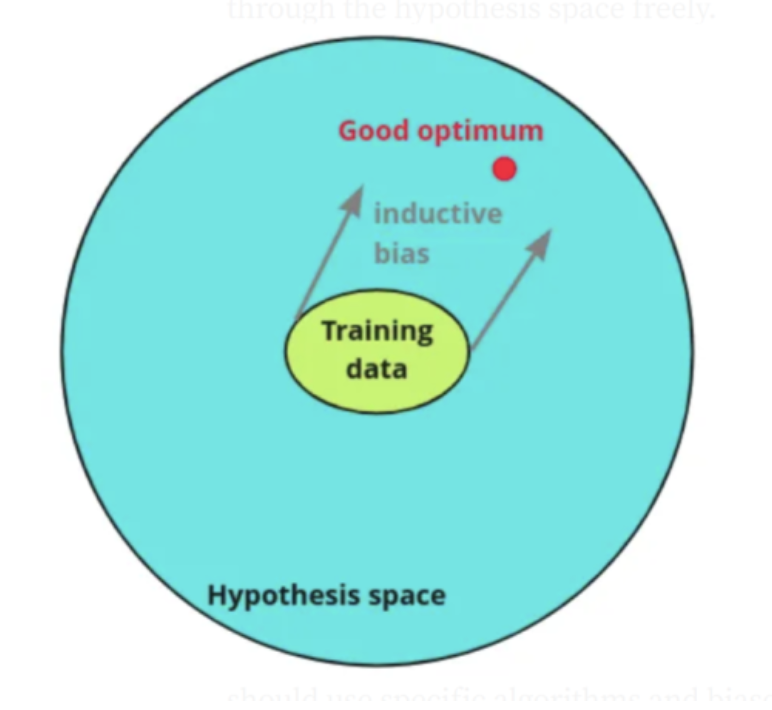

inductive bias란 간단하게 모델이 데이터를 학습할 때, 여러 가능한 규칙 중 특정한 규칙을 더 선호하도록 만드는 가정이나 성향을 말한다.    

CNN과 ResNet과 같은 모델들은 Transformer보다 inductive bias가 강하다. 따라서 초기에 단순히 이미지를 patch로 자르고 NLP에서 사용하던 Transformer에 넣어본 결과 ImageNet(1.3M) 규모에서 ResNet보다 성능이 낮게 나왔다. 이러한 결과를 보고 세우게 된 가설은 Transformer는 CNN보다 inductive bias이 약하고 Locality도, Translation Equivariance도 없다. 따라서 데이터가 적을 때 학습 효율이 낮은 것 아닐까?라는 것이다. 이후, 대규모 데이터인 JFT-300M으로 Pre-training을 해본 결과 ViT가 ResNet을 이겼다.

![ViT vs ResNet transfer accuracy versus pre-training data size](../assets/figures/vit_fig3_transfer_imagenet.png)

*Figure: Transfer to ImageNet vs. pre-training size (ViT paper, Dosovitskiy et al. 2021). ViT-B/32, ViT-L/32는 데이터가 적을 때(~10M) ResNet(R50x1, R152x2)보다 낮지만, 데이터가 커질수록(~300M) ResNet을 추월한다. → convolutional inductive bias는 작은 데이터에서 유리하고, 데이터가 충분히 크면 패턴을 데이터에서 직접 학습하는 편이 낫다.*

따라서 ViT는 bias가 약한 대신 데이터로부터 직접 배우는 것의 정확도가 더 크다는 것을 보인 것이다. 그래서 이 논문 이후 vision 연구의 방향 자체가 "구조를 잘 설계하기"에서 "데이터·규모를 키우기"로 옮겨가게 되었다.

---
## Evolution of architectures

![Evolution of architectures: FC to CNN to RNN to Transformer to ViT](../assets/figures/evolution_of_architectures.png)


- FC는 모든 입력을 모든 출력에 연결하여, 구조 가정이 전혀 없었고 이미지엔 파라미터가 너무 많았다.   

- CNN은 FC와 달리 locality, weight sharing을 써서 이미지의 공간 구조를 활용하였다.   

- RNN은 CNN과 달리 Sequential/temporal dependencies을 명시적으로 모델링하였다.   

- Transformer는 RNN과 달리 순차 recurrence 없이 attention으로 장거리 관계를 직접 모델링하였다.   

- ViT는 CNN과 달리 vision에 특화된 inductive bias 없이, 이미지를 patch token으로 만들어 순수 Transformer로 처리하였다.   

---

## Python Basics Summary

### 1) 변수

#### ex)

In [ ]:
d_model = 768
name = "ViT"
scale = 0.125

### 2)리스트

#### ex)

In [ ]:
layers = [0, 1, 2, 3]
layers[0]  # 0   ← 첫 번째는 0번
layers[-1]  # 3   ← 마지막
layers[1:3]  # [1, 2]  ← 1번부터 3번 앞까지
len(layers)  # 4

** 파이썬은 0부터 센다 **

### 3) 딕셔너리

#### ex)

In [ ]:
config = {"depth": 12, "heads": 12, "dim": 768}
config["depth"]  # 12
config.keys()  # dict_keys(['depth', 'heads', 'dim'])

### 4) 반복

#### ex)

In [ ]:
for i in range(3):
    print(i)  # 0, 1, 2

In [ ]:
import numpy as np

all_attentions = [np.zeros((1, 12, 197, 197)) for _ in range(3)]  # 예시용 더미

for layer_idx, attn_map in enumerate(all_attentions):
    print(f"{layer_idx}번 레이어의 모양: {attn_map.shape}")

### 5) 조건

#### ex)

In [ ]:
import torch

device = "mps" if torch.backends.mps.is_available() else "cpu"

### 6) 함수

#### ex)

In [ ]:
from torch import softmax


def attention(q, k, v):
    scores = q @ k.T
    weights = softmax(scores)  # type: ignore
    return weights @ v

- def : 함수를 정의한다.   

- q, k, v : 받을 재료(인자).   

- return : 결과를 돌려준다.   


호출은 out = attention(q, k, v).

In [ ]:
def attention(q, k, v, scale=None):  # scale 안 주면 None  # noqa: F811
    ...

### 7) 클래스

#### ex)

In [ ]:
import numpy as np


def 랜덤행렬(rows, cols):
    return np.random.randn(rows, cols)


class Attention:
    def __init__(self, dim):  # 설계도: 부품을 만들 때 1번 실행
        self.dim = dim  # self = "나 자신"
        self.W_q = 랜덤행렬(dim, dim)
        self.W_k = 랜덤행렬(dim, dim)

    def forward(self, x):  # 사용법: 입력이 들어올 때마다 실행
        q = x @ self.W_q
        k = x @ self.W_k
        return q, k

함수는 받기→ 계산하기 → 돌려주기만 한다.   
그런데 신경망은 자기 안에 가중치를 계속 들고 있어야 한다. 그것을 들고 있는 것이 클래스이다.

In [ ]:
import numpy as np

x = np.random.randn(197, 768)  # 예시 입력 (토큰 197개, 각 768차원)

attn = Attention(dim=768)  # __init__ 실행됨 (부품 생산)
q, k = attn.forward(x)  # forward 실행됨 (부품 사용)

Torch에서는 nn.Module 을 상속받아 쓰고, forward 를 attn(x) 처럼 부를 수 있게 해준다.

In [ ]:
import torch
from torch import nn


class Attention(nn.Module):
    def __init__(self, dim):
        super().__init__()  # 부모(nn.Module) 준비를 먼저 시킴
        self.qkv = nn.Linear(dim, dim * 3)

    def forward(self, x):
        return self.qkv(x)


x = torch.randn(197, 768)  # 예시 입력
attn = Attention(768)
out = attn(x)  # ← .forward를 안 써도 됨. PyTorch가 연결함

### 8) import

In [ ]:
import torch  # torch.tensor(...)
from torch import nn  # nn.Linear(...)   ← 별명 붙이기
from torch.nn import functional as F  # F.softmax(...)  # noqa: F401


관례적으로 ```nn```, ```F```, ```np```, ```plt``` 로 줄여쓴다.